In [ ]:
import pandas as pd
from utils.funcs import get_variable_names, rename_columns, processed_diabetes_data, demographic_data2
from functools import reduce
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif



c:\Users\bipan\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def read_file(filename=''):

    dataset_path='raw_datasets'
    df=pd.read_sas(f'{dataset_path}/{filename}.XPT', format='xport')
    mapping=get_variable_names()
    df=rename_columns(df, mapping)  
    threshold = int(0.7 * len(df))  
    df = df.dropna(axis=1, thresh=threshold)
    return df

In [3]:
df_diabetes=processed_diabetes_data()  
df_demographic=demographic_data2()
df_audio=read_file('audiometry')
df_blood_pressure=read_file('blood_pressure_cholesterol')
df_general_health=read_file('hospital_utilization_access_to_care')
df_weight=read_file('weight_history')
df_occupation=read_file('occupation')
df_sleep=read_file('sleep_disorders')
df_smoke1=read_file('smoking_cigarette_use')
df_smoke2=read_file('smoking_household_smokers')
df_smoke3=read_file('smoking_recent_tobacco_use')
df_medication=read_file('prescription_medications')
df_phy_activity=read_file('physical_activity')
df_alcohol=read_file('alcohol_use')

In [4]:
dataframes = [df_diabetes,df_demographic, df_audio, df_blood_pressure, df_general_health, df_weight, df_occupation,df_sleep,df_smoke1,df_smoke2,df_smoke3,df_medication,df_phy_activity,df_alcohol]
df = reduce(lambda left, right: pd.merge(left, right, on='sequence_no', how='inner'), dataframes)

In [6]:
len(df.columns)

45

In [11]:
type(df['gender'][0])

numpy.float64

In [17]:
df1 = df.drop('sequence_no', axis=1)  
df1=df1.dropna()
df1 = df1.select_dtypes(exclude=['object', 'string'])


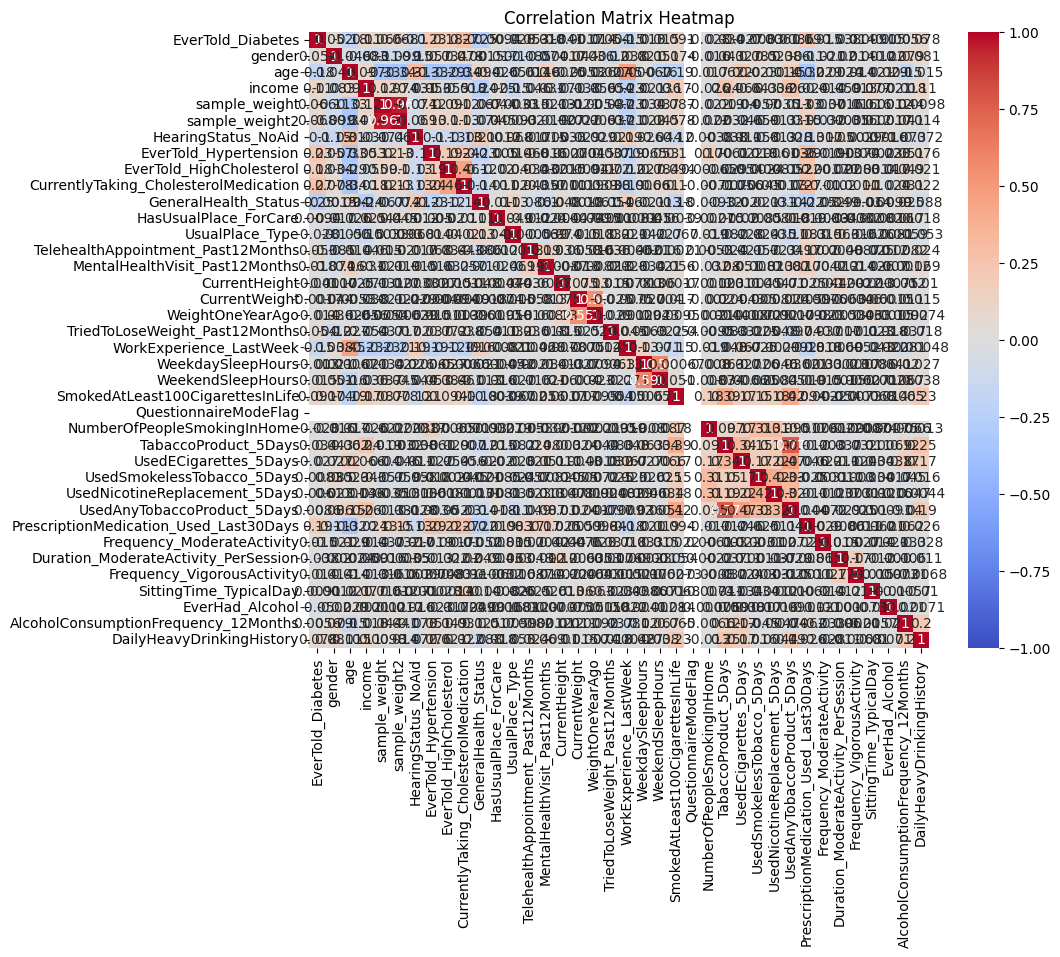

In [18]:
corr_matrix = df1.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [19]:
corr_matrix

,EverTold_Diabetes,gender,age,income,sample_weight,sample_weight2,HearingStatus_NoAid,EverTold_Hypertension,EverTold_HighCholesterol,CurrentlyTaking_CholesterolMedication,...,UsedNicotineReplacement_5Days,UsedAnyTobaccoProduct_5Days,PrescriptionMedication_Used_Last30Days,Frequency_ModerateActivity,Duration_ModerateActivity_PerSession,Frequency_VigorousActivity,SittingTime_TypicalDay,EverHad_Alcohol,AlcoholConsumptionFrequency_12Months,DailyHeavyDrinkingHistory
EverTold_Diabetes,1.000000,0.051860,-0.184414,0.108103,0.065872,0.067958,-0.104474,0.233952,0.181350,0.267023,...,-0.006144,0.008591,0.187141,0.014565,-0.037519,0.013839,0.009137,-0.049878,0.005590,0.078001
gender,0.051860,1.000000,-0.045846,-0.083498,-0.110523,-0.099095,-0.151484,0.056956,0.034213,0.077635,...,0.023014,0.085763,-0.106238,-0.021431,-0.020396,0.013648,0.001195,-0.020299,0.078996,0.081041
age,-0.184414,-0.045846,1.000000,0.096583,-0.327487,-0.343278,0.308150,-0.333767,-0.293295,-0.341986,...,-0.001436,0.151293,-0.323010,0.029412,0.002391,0.013845,-0.020786,0.028579,-0.152148,-0.014769
income,0.108103,-0.083498,0.096583,1.000000,0.116472,0.073659,-0.030526,0.052905,-0.055280,-0.018174,...,0.035652,0.256201,-0.024236,-0.013874,-0.059465,-0.012680,0.076711,0.002120,-0.017691,0.105066
sample_weight,0.065872,-0.110523,-0.327487,0.116472,1.000000,0.959720,-0.074327,0.123577,0.090180,0.122398,...,-0.003535,-0.013185,0.128191,-0.037264,0.001647,-0.016233,0.016456,0.001238,0.044451,0.009795
sample_weight2,0.067958,-0.099095,-0.343278,0.073659,0.959720,1.000000,-0.068935,0.127834,0.100627,0.130669,...,-0.012570,-0.031423,0.150548,-0.031526,-0.000352,-0.016012,0.012277,0.001722,0.041466,0.014114
HearingStatus_NoAid,-0.104474,-0.151484,0.308150,-0.030526,-0.074327,-0.068935,1.000000,-0.101567,-0.132493,-0.134297,...,-0.012512,-0.027694,-0.128481,0.017435,0.050498,-0.002860,0.007147,0.016193,-0.072702,-0.071755
EverTold_Hypertension,0.233952,0.056956,-0.333767,0.052905,0.123577,0.127834,-0.101567,1.000000,0.191661,0.240987,...,0.006074,-0.003563,0.285513,-0.019208,-0.012712,0.007414,-0.000232,-0.023137,0.051197,0.076153
EverTold_HighCholesterol,0.181350,0.034213,-0.293295,-0.055280,0.090180,0.100627,-0.132493,0.191661,1.000000,0.459002,...,0.008062,-0.051700,0.220410,-0.001717,-0.021641,0.008309,-0.001411,-0.016908,0.048580,0.020777
CurrentlyTaking_CholesterolMedication,0.267023,0.077635,-0.341986,-0.018174,0.122398,0.130669,-0.134297,0.240987,0.459002,1.000000,...,-0.000171,-0.030282,0.274207,-0.010280,-0.019965,0.001084,0.104249,-0.024259,0.030867,0.022237


In [ ]:

scores = mutual_info_classif(df1.drop('EverTold_Diabetes', axis=1), df1['EverTold_Diabetes'])


In [24]:
for i, score in enumerate(scores):
    print(f"Feature {i}: MI score = {score:.4f}")

Feature 0: MI score = 0.0047
Feature 1: MI score = 0.0216
Feature 2: MI score = 0.0080
Feature 3: MI score = 0.0000
Feature 4: MI score = 0.0000
Feature 5: MI score = 0.0029
Feature 6: MI score = 0.0456
Feature 7: MI score = 0.0279
Feature 8: MI score = 0.0507
Feature 9: MI score = 0.0328
Feature 10: MI score = 0.0135
Feature 11: MI score = 0.0068
Feature 12: MI score = 0.0000
Feature 13: MI score = 0.0000
Feature 14: MI score = 0.0015
Feature 15: MI score = 0.0192
Feature 16: MI score = 0.0163
Feature 17: MI score = 0.0000
Feature 18: MI score = 0.0080
Feature 19: MI score = 0.0018
Feature 20: MI score = 0.0037
Feature 21: MI score = 0.0159
Feature 22: MI score = 0.0009
Feature 23: MI score = 0.0094
Feature 24: MI score = 0.0062
Feature 25: MI score = 0.0034
Feature 26: MI score = 0.0044
Feature 27: MI score = 0.0028
Feature 28: MI score = 0.0041
Feature 29: MI score = 0.0216
Feature 30: MI score = 0.0000
Feature 31: MI score = 0.0000
Feature 32: MI score = 0.0055
Feature 33: MI score

In [27]:
df1.var()

EverTold_Diabetes                         1.034394e-01
gender                                    2.470276e-01
age                                       3.071126e+02
income                                    2.633864e+00
sample_weight                             4.516121e+08
sample_weight2                            8.276928e+08
HearingStatus_NoAid                       1.089872e+00
EverTold_Hypertension                     2.634517e-01
EverTold_HighCholesterol                  4.237162e-01
CurrentlyTaking_CholesterolMedication     3.047621e-01
GeneralHealth_Status                      9.175127e-01
HasUsualPlace_ForCare                     3.143230e-02
UsualPlace_Type                           6.367866e-01
TelehealthAppointment_Past12Months        3.099375e-01
MentalHealthVisit_Past12Months            2.004769e-01
CurrentHeight                             2.597909e+05
CurrentWeight                             6.076441e+05
WeightOneYearAgo                          8.956733e+05
TriedToLos

In [29]:
df1.columns

Index(['EverTold_Diabetes', 'gender', 'age', 'income', 'sample_weight',
       'sample_weight2', 'HearingStatus_NoAid', 'EverTold_Hypertension',
       'EverTold_HighCholesterol', 'CurrentlyTaking_CholesterolMedication',
       'GeneralHealth_Status', 'HasUsualPlace_ForCare', 'UsualPlace_Type',
       'TelehealthAppointment_Past12Months', 'MentalHealthVisit_Past12Months',
       'CurrentHeight', 'CurrentWeight', 'WeightOneYearAgo',
       'TriedToLoseWeight_Past12Months', 'WorkExperience_LastWeek',
       'WeekdaySleepHours', 'WeekendSleepHours',
       'SmokedAtLeast100CigarettesInLife', 'QuestionnaireModeFlag',
       'NumberOfPeopleSmokingInHome', 'TabaccoProduct_5Days',
       'UsedECigarettes_5Days', 'UsedSmokelessTobacco_5Days',
       'UsedNicotineReplacement_5Days', 'UsedAnyTobaccoProduct_5Days',
       'PrescriptionMedication_Used_Last30Days', 'Frequency_ModerateActivity',
       'Duration_ModerateActivity_PerSession', 'Frequency_VigorousActivity',
       'SittingTime_TypicalD

In [31]:
category_cols=['gender', 'HearingStatus_NoAid', 'EverTold_Hypertension','EverTold_HighCholesterol','CurrentlyTaking_CholesterolMedication','GeneralHealth_Status','WorkExperience_LastWeek','SmokedAtLeast100CigarettesInLife','PrescriptionMedication_Used_Last30Days']
df1_encoded = pd.get_dummies(df1, columns=category_cols)


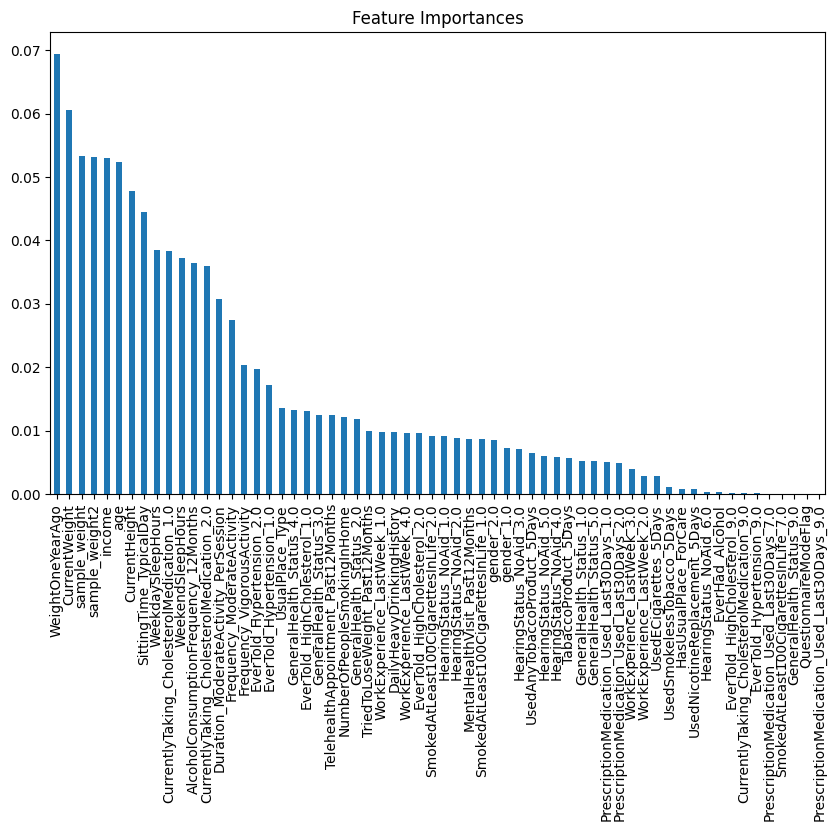

In [33]:
model = RandomForestClassifier()
model.fit(df1_encoded.drop('EverTold_Diabetes', axis=1), df1_encoded['EverTold_Diabetes'])

feature_importances = pd.Series(model.feature_importances_, index=df1_encoded.drop('EverTold_Diabetes', axis=1).columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances")
plt.show()

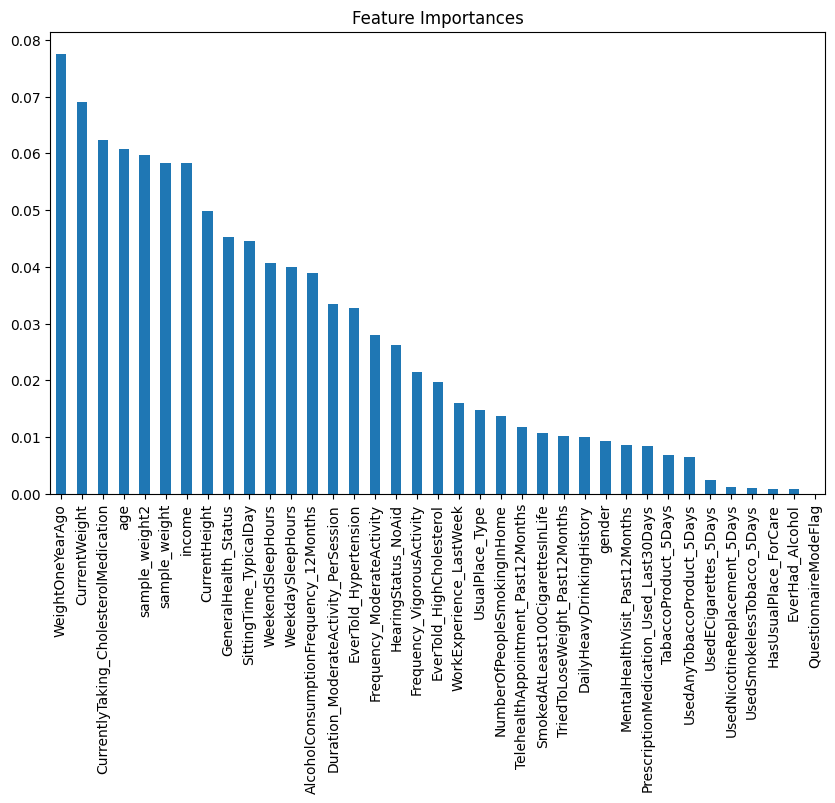

In [34]:
model = RandomForestClassifier()
model.fit(df1.drop('EverTold_Diabetes', axis=1), df1['EverTold_Diabetes'])

feature_importances = pd.Series(model.feature_importances_, index=df1.drop('EverTold_Diabetes', axis=1).columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances")
plt.show()

In [35]:
from sklearn.linear_model import LogisticRegression


c:\Users\bipan\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


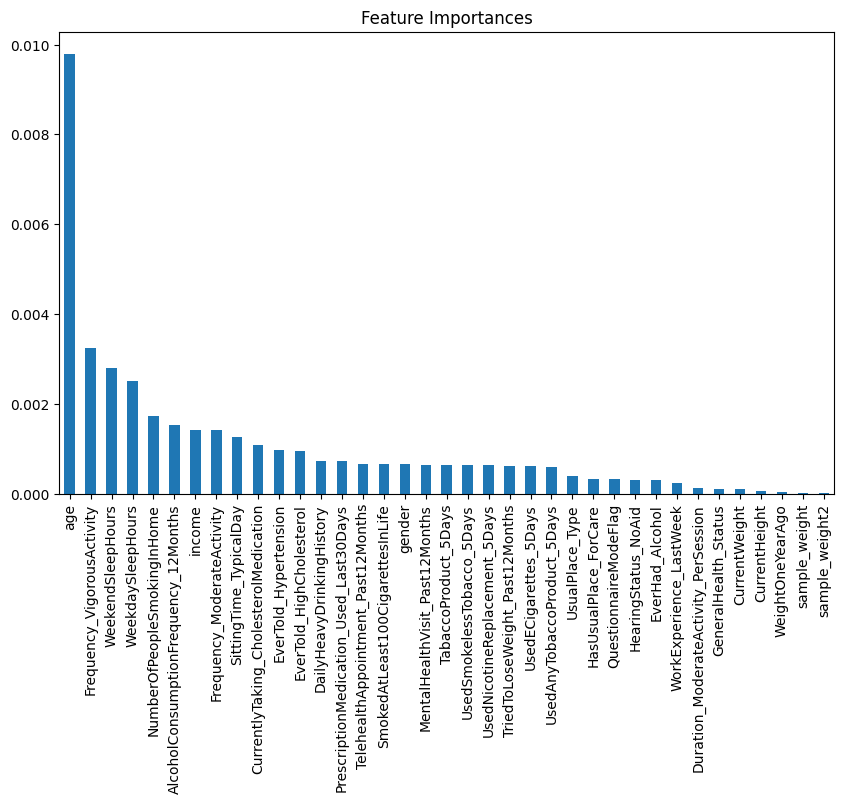

In [37]:
model = LogisticRegression(random_state=42)
model.fit(df1.drop('EverTold_Diabetes', axis=1), df1['EverTold_Diabetes'])

feature_importances = pd.Series(abs(model.coef_[0]), index=df1.drop('EverTold_Diabetes', axis=1).columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances")
plt.show()

c:\Users\bipan\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


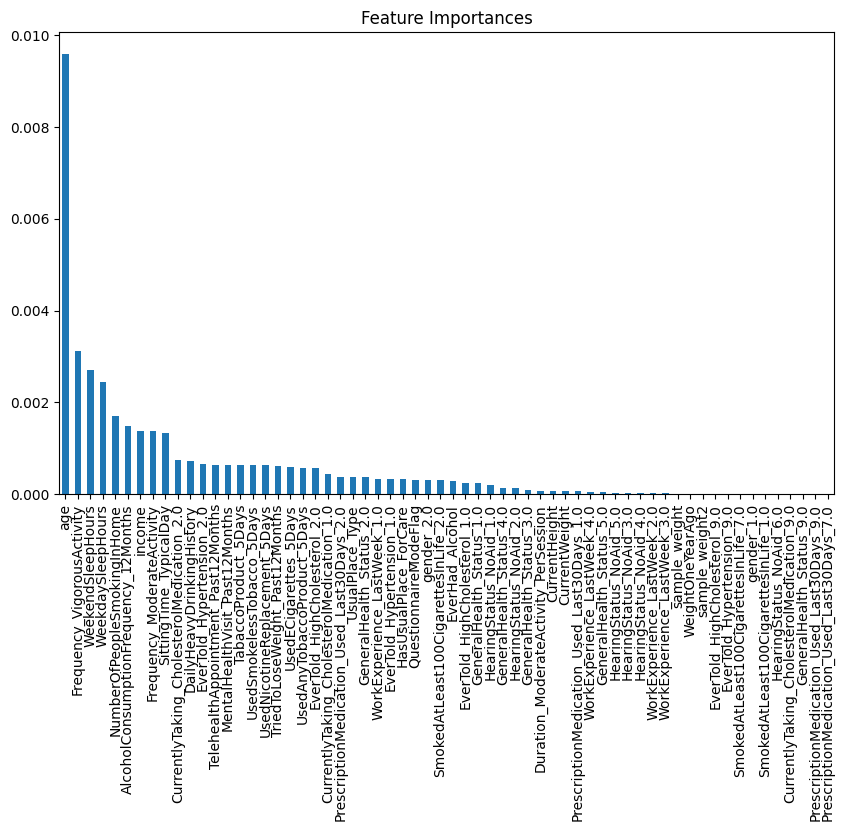

In [38]:
model = LogisticRegression(random_state=42)
model.fit(df1_encoded.drop('EverTold_Diabetes', axis=1), df1_encoded['EverTold_Diabetes'])

feature_importances = pd.Series(abs(model.coef_[0]), index=df1_encoded.drop('EverTold_Diabetes', axis=1).columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances")
plt.show()

In [43]:
numerical_cols = df1.columns.difference(category_cols+['EverTold_Diabetes'])


Accuracy: 0.8748
Precision: 0.4737
Recall: 0.1200
F1 Score: 0.1915


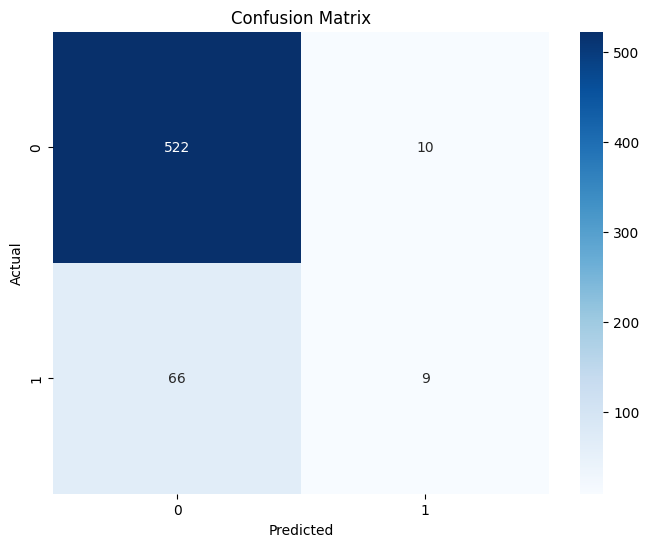

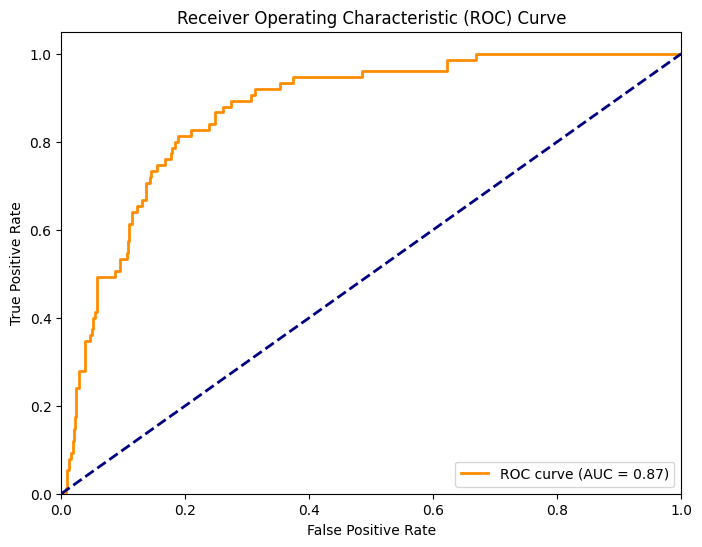

In [ ]:

# Prepare the data
X = df1_encoded.drop('EverTold_Diabetes', axis=1)
y = df1_encoded['EverTold_Diabetes'].map({1.0: 1, 2.0: 0})

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

# Scale the features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Create and fit the model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve, auc
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [ ]:
def objective(trial, sampling=None):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
        "feature_fraction": trial.suggest_uniform("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_uniform("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_loguniform("lambda_l1", 1e-8, 10.0),
        "lambda_l2": trial.suggest_loguniform("lambda_l2", 1e-8, 10.0),
    }

    train_data = lgb.Dataset(X_train, label=y_train)
    # train_data = lgb.Dataset(X_resampled, label=y_resampled)
    valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

    scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
    params["scale_pos_weight"] = scale_pos_weight

    model = lgb.train(
        params,
        train_data,
        valid_sets=[valid_data],
        valid_names=["valid"],
        num_boost_round=500,
        callbacks=[
            lgb.early_stopping(stopping_rounds=30),
            lgb.log_evaluation(period=50),
        ],
    )

    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)

    return auc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  

best_params = study.best_params
# print("Best Parameters:", best_params)

In [64]:



train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
best_params["scale_pos_weight"] = scale_pos_weight

model = lgb.train(
    best_params,
    train_data,
    valid_sets=[valid_data],
    valid_names=["valid"],
    num_boost_round=500,
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(period=50),
    ],
)

y_pred_proba = model.predict(X_test)  
y_pred = (y_pred_proba > 0.5).astype(int)  

auroc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001422 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1353
[LightGBM] [Info] Number of data points in the train set: 2424, number of used features: 49
[LightGBM] [Info] Start training from score 0.115512
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 30 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [66]:
auroc,accuracy

(np.float64(0.8590476190476191), 0.8780889621087314)

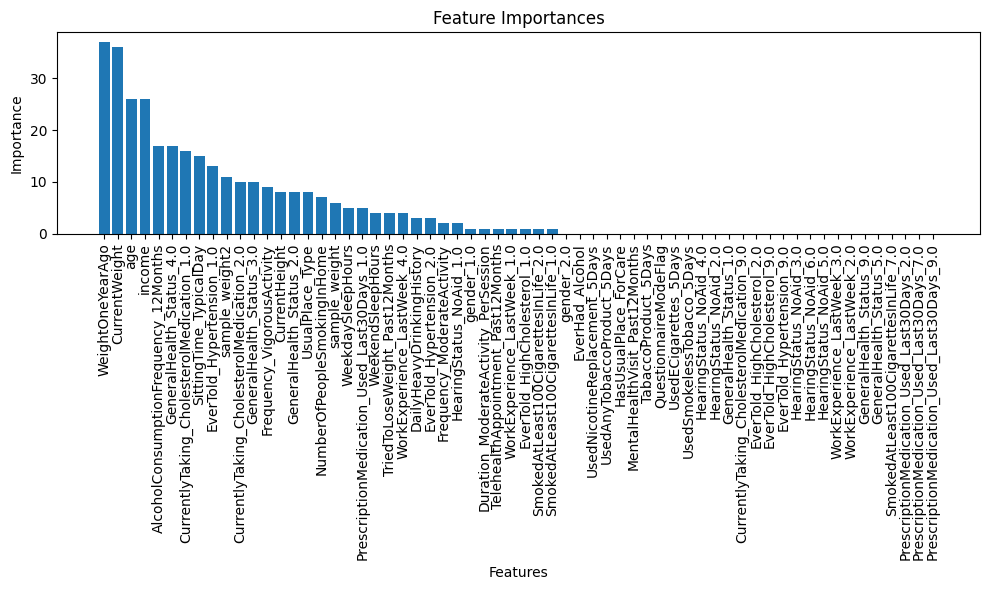

                                      Feature  Importance
10                           WeightOneYearAgo          37
9                               CurrentWeight          36
0                                         age          26
1                                      income          26
26       AlcoholConsumptionFrequency_12Months          17
48                   GeneralHealth_Status_4.0          17
42  CurrentlyTaking_CholesterolMedication_1.0          16
24                     SittingTime_TypicalDay          15
36                  EverTold_Hypertension_1.0          13
3                              sample_weight2          11


In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
feature_imp = pd.DataFrame({'Feature': X_train.columns, 
                            'Importance': model.feature_importance()})

# Sort features by importance
feature_imp = feature_imp.sort_values('Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(feature_imp['Feature'], feature_imp['Importance'])
plt.title('Feature Importances')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Print top 10 most important features
print(feature_imp.head(10))


Epoch 1/50


c:\Users\bipan\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7973 - auc: 0.5521 - loss: 0.5039 - val_accuracy: 0.8764 - val_auc: 0.7282 - val_loss: 0.3606
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8979 - auc: 0.6937 - loss: 0.3140 - val_accuracy: 0.8764 - val_auc: 0.7821 - val_loss: 0.3269
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8859 - auc: 0.7775 - loss: 0.3066 - val_accuracy: 0.8764 - val_auc: 0.8138 - val_loss: 0.3061
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8764 - auc: 0.7964 - loss: 0.3138 - val_accuracy: 0.8781 - val_auc: 0.8341 - val_loss: 0.2960
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8798 - auc: 0.7970 - loss: 0.3062 - val_accuracy: 0.8764 - val_auc: 0.8431 - val_loss: 0.2903
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8936 - auc: 0.8233 - loss: 0.2714 - val_accuracy: 0.8748 - val_auc: 0.8512 - val_loss: 0.2842
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0

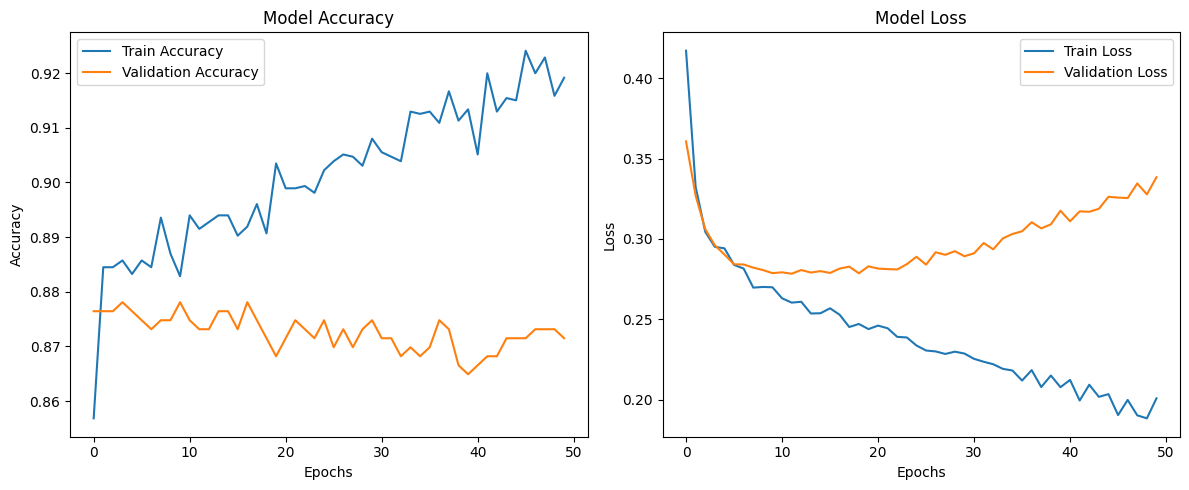

In [76]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score



# Build a 2-layer MLP model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # First hidden layer with 64 neurons
    Dropout(0.3),  # Dropout to prevent overfitting
    Dense(64, activation='relu'),  # Second hidden layer with 32 neurons
    Dense(1, activation='sigmoid')  # Output layer with sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# Train the model
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    verbose=1)

# Evaluate the model on the test set
loss, accuracy, auc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC-ROC: {auc:.4f}")

# Predict probabilities for AUC-ROC calculation
y_pred_proba = model.predict(X_test).flatten()

# Calculate AUC-ROC using sklearn for verification
auc_roc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score (sklearn): {auc_roc:.4f}")

# Plot training history (accuracy and loss)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
